# Reading the Data

In [1]:
import pandas as pd
df_matched = pd.read_excel("cb_12_24_delirium_final.xlsx")

In [3]:
print(df_matched.columns.tolist())


['case', 'study_id', 'study_enc_id', 'study_case_id', 'duration', 'outcome', 'del_1', 'del_8', 'year-proc', 'sex', 'race', 'ethnicity', 'age', 'asa_class', 'age.1', 'asa_class.1', 'asa1', 'asa1e', 'asa2', 'asa2e', 'asa3', 'asa3e', 'asa4', 'asa4e', 'asa5', 'asa5e', 'asa6', 'asa6e', 'CCI', 'cisatracurium', 'hydromorphone', 'midazolam', 'dexmedetomidine', 'etomidate', 'fentanyl', 'ketamine', 'morphine', 'propofol', 'remifentanil', 'rocuronium', 'succinylcholine', 'vecuronium', 'map_mean', 'map_min', 'map_max', 'esmolol', 'hydralazine', 'labetalol', 'metoprolol', 'nicardipine', 'epinephrine', 'norepinephrine', 'phenylephrine', 'ephedrine', 'vasopressin', 'SE', 'Anemia', 'CKD', 'COPD', 'Cancer', 'Cancer METS', 'Cardiac arrhythmia', 'Cerebral Vascular Dz', 'Chr Dialysis', 'Chr ETOH', 'Chr heart failure', 'Diabetes', 'Drug Abuse', 'HTN', 'Heart valve dz', 'Hemiplegia/Paraplegia', 'Ischemic heart dz', 'LIVER DZ', 'Obesity', 'Peripheral vascular disease', 'Psychiatric Disorders', 'Pulmonaru Vas

# Data Preprocessing

In [ ]:
df_dropped = df_matched.drop(columns=['outcome','del_8', 'age.1', 'asa_class.1', 'inhal_anesthesia'], errors="ignore")
df_dropped

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_dropped = df_dropped.rename(columns={
    "Pulmonaru Vasular Dz": "Pulmonary Vascular Disease",
    "Antispasmotics": "Antispasmodics"
})

In [ ]:
df_dropped['NORA'] = ((df_dropped['EP/PACEMAKER'] == 1) | (df_dropped['GI-NORA'] == 1)).astype(int)

In [ ]:
df_dropped = df_dropped.drop(columns=['EP/PACEMAKER','GI-NORA'], errors="ignore")
df_dropped

## Medication Class Binarization (Presence/Absence Encoding)

In [11]:
mask_cols = [
    'Antispasmodics', 'peri-op sedatives', #'anti histaminics' and 'anti-arrhythmics' removed already
    'periop-antihypertensives', 'Gastrointestinal Agents',
    'opioids and NSAIDS', 'psychoactive and anticonvulsant ',
    'steroids', 'antibiotics'
]

# Keep originals with suffix "_orig"
for col in mask_cols:
    df_dropped[col + "_orig"] = df_dropped[col]
    df_dropped[col] = (df_dropped[col] > 0).astype(int)   

In [12]:
# Clean column names (strip, lower, replace spaces)
df_dropped.columns = (
    df_dropped.columns
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
)

## Feature Engineering for ASA Class and Emergency Status

In [14]:
# Step 1: Drop "_orig" columns
df_mod = df_dropped.loc[:, ~df_dropped.columns.str.endswith("_orig")].copy()
print(f"Dropped _orig columns. Remaining columns: {df_mod.shape[1]}")

# Step 2: Create ASA numeric and emergency flag
# ASA class numeric: extract from asa_class (if present)
if "asa_class" in df_mod.columns:
    # Coerce text to numeric safely
    df_mod["asa_class_num"] = (
        df_mod["asa_class"]
        .astype(str)
        .str.extract(r"(\d)")
        .astype(float)
    )

# Emergency flag: 1 if any of the ASA_emergency variants (asa1e–asa6e) are 1
asa_emerg_cols = [c for c in df_mod.columns if c.lower().startswith("asa") and c.lower().endswith("e")]
df_mod["asa_emerg_flag"] = df_mod[asa_emerg_cols].max(axis=1) if asa_emerg_cols else 0

# Step 3: Drop individual ASA one-hot columns (asa1–asa6 and asa1e–asa6e)
asa_cols_to_drop = [c for c in df_mod.columns if c.lower().startswith("asa") and (c.lower().endswith(tuple(str(i) for i in range(1, 7))) or c.lower().endswith(tuple(f"{i}e" for i in range(1, 7))))]
df_mod.drop(columns=asa_cols_to_drop, inplace=True, errors="ignore")

print(f"Created asa_class_num + asa_emerg_flag and dropped {len(asa_cols_to_drop)} ASA dummies.")
print(df_mod[["asa_class", "asa_class_num", "asa_emerg_flag"]].head())


Dropped _orig columns. Remaining columns: 98
Created asa_class_num + asa_emerg_flag and dropped 12 ASA dummies.
  asa_class  asa_class_num  asa_emerg_flag
0         3            3.0               0
1         3            3.0               0
2         3            3.0               0
3         3            3.0               0
4         4            4.0               0


## Phik-Based Feature Correlation Screening

In [ ]:
df_mod = df_mod.drop(columns=['case','case_control'], errors="ignore")
df_mod

In [18]:
#1. Drop redundant column
df_phik = df_mod.drop(columns=["asa_class"], errors="ignore").copy()

# 2. Import and compute Phik correlation matrix
from phik import phik_matrix
from phik.report import plot_correlation_matrix
import numpy as np, pandas as pd

# Numeric columns (for better binning)
interval_cols = df_phik.select_dtypes(include=["number"]).columns.tolist()

# Compute Phik correlation matrix
phik_mat = phik_matrix(df_phik, interval_cols=interval_cols)

# 3. Flatten into long-form pairs
np.fill_diagonal(phik_mat.values, np.nan)
mask_upper = np.triu(np.ones_like(phik_mat, dtype=bool), k=1)
pairs = (
    phik_mat.where(mask_upper)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "col1", "level_1": "col2", 0: "phik"})
            .sort_values("phik", ascending=False)
)

# 4. View highly correlated pairs (>|0.8|)
high_pairs = pairs.loc[pairs["phik"] > 0.8].reset_index(drop=True)
print("Highly correlated pairs (>|0.8|):")
print(high_pairs.head(50).to_string(index=False))


Highly correlated pairs (>|0.8|):
         col1                            col2     phik
 study_enc_id                   study_case_id 0.999917
     ketamine psychoactive and anticonvulsant 0.998880
    midazolam               peri-op sedatives 0.996786
study_case_id                       year-proc 0.990332
 study_enc_id                       year-proc 0.989978
     fentanyl              opioids and NSAIDS 0.973999
          CKD                    Chr Dialysis 0.970505
   metoprolol        periop-antihypertensives 0.948752
     Chr ETOH                      Drug Abuse 0.838903


In [20]:
# Drop redundant high-correlation features
drop_cols = [
    "psychoactive and anticonvulsant",
    "peri-op sedatives",
    "Chr Dialysis",
    "opioids and NSAIDS",
    "periop-antihypertensives",
    "Drug Abuse",
    "asa_class"
]

df_mod = df_mod.drop(columns=drop_cols, errors="ignore")

print(f"Dropped {len(drop_cols)} highly correlated columns:")
print(drop_cols)
print(f"\nRemaining columns: {df_mod.shape[1]}")


Dropped 7 highly correlated columns:
['psychoactive and anticonvulsant', 'peri-op sedatives', 'Chr Dialysis', 'opioids and NSAIDS', 'periop-antihypertensives', 'Drug Abuse', 'asa_class']

Remaining columns: 79


In [21]:
unique_names = df_mod['ethnicity'].unique()
print(unique_names)

['Not Hispanic or Latino' 'Unknown' nan 'Hispanic or Latino' 'Declined']


In [22]:
print(df_mod.columns.tolist())


['study_id', 'study_enc_id', 'study_case_id', 'duration', 'del_1', 'year-proc', 'sex', 'race', 'ethnicity', 'age', 'CCI', 'cisatracurium', 'hydromorphone', 'midazolam', 'dexmedetomidine', 'etomidate', 'fentanyl', 'ketamine', 'morphine', 'propofol', 'remifentanil', 'rocuronium', 'succinylcholine', 'vecuronium', 'map_mean', 'map_min', 'map_max', 'esmolol', 'hydralazine', 'labetalol', 'metoprolol', 'nicardipine', 'epinephrine', 'norepinephrine', 'phenylephrine', 'ephedrine', 'vasopressin', 'SE', 'Anemia', 'CKD', 'COPD', 'Cancer', 'Cancer METS', 'Cardiac arrhythmia', 'Cerebral Vascular Dz', 'Chr ETOH', 'Chr heart failure', 'Diabetes', 'HTN', 'Heart valve dz', 'Hemiplegia/Paraplegia', 'Ischemic heart dz', 'LIVER DZ', 'Obesity', 'Peripheral vascular disease', 'Psychiatric Disorders', 'Pulmonaru Vasular Dz', 'Resp Failure', 'Transplanted Organ', 'Antispasmotics', 'Gastrointestinal Agents', 'steroids', 'antibiotics', 'total_mac_hrs', 'inhal_anesthesia', 'General Surgery', 'Vascular', 'Orthoped

## Missing values check and imputation

In [22]:
# Missing value summary for df_dropped
import pandas as pd

missing_summary = (
    df_mod.isna()
    .sum()
    .to_frame("n_missing")
    .assign(pct_missing=lambda d: 100 * d["n_missing"] / len(df_mod))
    .query("n_missing > 0")  # only columns with missing values
    .sort_values("pct_missing", ascending=False)
)

print("=== Missing value summary (only columns with >0 missing) ===")
display(missing_summary.head(30))  # show top 30 for quick scan
print(f"\nTotal columns with missing values: {missing_summary.shape[0]}")
print(f"Total rows: {len(df_mod)}")


=== Missing value summary (only columns with >0 missing) ===


,n_missing,pct_missing
ethnicity,27,0.501300
asa_class_num,1,0.018567



Total columns with missing values: 2
Total rows: 5386


In [23]:
# Handle missing values in df_mod
df_mod = df_mod.copy()

# 1) Fill missing ethnicity with 'Unknown'
df_mod["ethnicity"] = df_mod["ethnicity"].fillna("Unknown")

if "asa_class_num" in df_mod.columns:
    median_asa_num = df_mod["asa_class_num"].median()
    df_mod["asa_class_num"] = df_mod["asa_class_num"].fillna(median_asa_num)

# Quick verification
print("Remaining missing values after imputation:")
print(df_mod.isna().sum().loc[lambda x: x > 0])


Remaining missing values after imputation:
Series([], dtype: int64)


# Feature Schema Definition for Reproducible Modeling

In [24]:
# Build & save feature schema from df_mod
import json, numpy as np, pandas as pd
from pathlib import Path

TARGET = "del_1"

# Exclude IDs & admin columns from features, but keeping them in df_mod for CV grouping
ID_COLS = ["study_id", "study_enc_id", "study_case_id"]
ADMIN_COLS = ["year-proc"]  # asa_class_num stays as continuous
EXCLUDE = [TARGET] + ID_COLS + ADMIN_COLS

df = df_mod.copy()

# 1) Constants (<=1 unique non-null)
constant_cols = (
    df.drop(columns=EXCLUDE, errors="ignore")
      .nunique(dropna=True)
      .pipe(lambda s: s[s <= 1].index.tolist())
)

# 2) Split by dtype
num_like = df.select_dtypes(include=[np.number, "boolean", "bool"]) \
             .drop(columns=EXCLUDE + constant_cols, errors="ignore")
obj_like = df.select_dtypes(include=["object", "category"]) \
             .drop(columns=EXCLUDE + constant_cols, errors="ignore")

# 3) Detect strict 0/1 binaries among numerics
def is_binary(series: pd.Series) -> bool:
    vals = pd.Series(series).dropna().unique()
    return len(vals) > 0 and set(vals).issubset({0, 1})

binary_cols = [c for c in num_like.columns if is_binary(num_like[c])]
continuous_cols = sorted(set(num_like.columns) - set(binary_cols))
categorical_cols = sorted(obj_like.columns.tolist())

# 4) Enforce ASA design explicitly (keeping numeric; flagging emergency as binary)
if "asa_class_num" in df.columns:
    if "asa_class_num" in binary_cols:   binary_cols.remove("asa_class_num")
    if "asa_class_num" not in continuous_cols and "asa_class_num" not in constant_cols:
        continuous_cols.append("asa_class_num")

if "asa_emerg_flag" in df.columns and is_binary(df["asa_emerg_flag"]):
    if "asa_emerg_flag" in continuous_cols: continuous_cols.remove("asa_emerg_flag")
    if "asa_emerg_flag" not in binary_cols and "asa_emerg_flag" not in constant_cols:
        binary_cols.append("asa_emerg_flag")

# 5) Final feature list (excluding target, IDs, admin, constants)
feature_list = [c for c in df.columns if c not in set(EXCLUDE + constant_cols)]

# Ensure mutual exclusivity across buckets (priority: categorical > binary > continuous)
seen = set(); final_cats, final_bins, final_conts = [], [], []
for c in sorted(categorical_cols):
    if c in feature_list and c not in seen: final_cats.append(c); seen.add(c)
for c in sorted(binary_cols):
    if c in feature_list and c not in seen: final_bins.append(c); seen.add(c)
for c in sorted(continuous_cols):
    if c in feature_list and c not in seen: final_conts.append(c); seen.add(c)

# Ordered feature list
feature_list = final_conts + final_cats + final_bins

# 6) Label stats
label_stats = {TARGET: float(pd.Series(df[TARGET]).mean())}

# 7) Save schema
schema = {
    "target": TARGET,
    "aux_outcomes": [],
    "binary_cols": sorted(final_bins),
    "continuous_cols": sorted(final_conts),
    "categorical_cols": sorted(final_cats),
    "constant_cols": sorted(constant_cols),
    "feature_list": feature_list,
    "dtypes": {c: str(df[c].dtype) for c in feature_list},
    "label_stats": label_stats,
    "exclude_cols": EXCLUDE,        # helpful breadcrumb
    "id_cols": ID_COLS,             # for grouping later
}

Path("artifacts").mkdir(exist_ok=True)
with open("artifacts/feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Saved → artifacts/feature_schema.json")
print(f"Counts → continuous={len(schema['continuous_cols'])}, categorical={len(schema['categorical_cols'])}, binary={len(schema['binary_cols'])}, constants={len(schema['constant_cols'])}")
print("Categoricals:", schema["categorical_cols"])
print("Target prevalence:", f"{schema['label_stats'][TARGET]:.3f}")
print("Excluded (not modeled):", EXCLUDE)


Saved → artifacts/feature_schema.json
Counts → continuous=11, categorical=3, binary=60, constants=0
Categoricals: ['ethnicity', 'race', 'sex']
Target prevalence: 0.500
Excluded (not modeled): ['del_1', 'study_id', 'study_enc_id', 'study_case_id', 'year-proc']


In [24]:
continuous_cols

['CCI',
 'age',
 'asa_class_num',
 'duration',
 'map_65_95_min',
 'map_gt_95_min',
 'map_lt_65_min',
 'map_max',
 'map_mean',
 'map_min',
 'total_mac_hrs']

In [21]:
binary_cols

['cisatracurium',
 'hydromorphone',
 'midazolam',
 'dexmedetomidine',
 'etomidate',
 'fentanyl',
 'ketamine',
 'morphine',
 'propofol',
 'remifentanil',
 'rocuronium',
 'succinylcholine',
 'vecuronium',
 'esmolol',
 'hydralazine',
 'labetalol',
 'metoprolol',
 'nicardipine',
 'epinephrine',
 'norepinephrine',
 'phenylephrine',
 'ephedrine',
 'vasopressin',
 'SE',
 'Anemia',
 'CKD',
 'COPD',
 'Cancer',
 'Cancer METS',
 'Cardiac arrhythmia',
 'Cerebral Vascular Dz',
 'Chr ETOH',
 'Chr heart failure',
 'Diabetes',
 'HTN',
 'Heart valve dz',
 'Hemiplegia/Paraplegia',
 'Ischemic heart dz',
 'LIVER DZ',
 'Obesity',
 'Peripheral vascular disease',
 'Psychiatric Disorders',
 'Pulmonary Vascular Disease',
 'Resp Failure',
 'Transplanted Organ',
 'Antispasmodics',
 'Gastrointestinal Agents',
 'steroids',
 'antibiotics',
 'General Surgery',
 'Vascular',
 'Orthopedics',
 'Thoracic',
 'Neurosurgery',
 'GYN',
 'GU',
 'ENT',
 'EYE',
 'NORA',
 'asa_emerg_flag']

In [26]:
categorical_cols

['ethnicity', 'race', 'sex']

# Unfitted Feature Preprocessing for Cross-Validated Modeling

In [25]:
# A) Build & save UNFITTED preprocessor (no leakage, no model)
import json
import joblib
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# 0) Loading schema produced earlier
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)

TARGET            = schema["target"]
continuous_cols   = schema["continuous_cols"]
categorical_cols  = schema["categorical_cols"]
binary_cols       = schema["binary_cols"]
EXCLUDED          = schema.get("exclude_cols", [])
ID_COLS           = schema.get("id_cols", ["study_id", "study_enc_id", "study_case_id"])

# 1) Resolve columns actually present in df_mod (guard against drift)
present_cont = [c for c in continuous_cols  if c in df_mod.columns]
present_cat  = [c for c in categorical_cols if c in df_mod.columns]
present_bin  = [c for c in binary_cols      if c in df_mod.columns]

# Safety: ensure excluded + target are not in any present_* lists
ban = set(EXCLUDED + [TARGET])
present_cont = [c for c in present_cont if c not in ban]
present_cat  = [c for c in present_cat  if c not in ban]
present_bin  = [c for c in present_bin  if c not in ban]

# 2) Define unfitted transformers
try:
    # Newer sklearn (>=1.2)
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    # Older sklearn
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

cont_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  RobustScaler()),
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    ohe),
])

bin_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])

# 3) ColumnTransformer (UNFITTED) - no fit/transform here
preprocessor = ColumnTransformer(
    transformers=[
        ("cont", cont_pipe, present_cont),
        ("cat",  cat_pipe,  present_cat),
        ("bin",  bin_pipe,  present_bin),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# 4) Save the unfitted preprocessor and a spec for reproducibility
Path("artifacts").mkdir(exist_ok=True)
joblib.dump(preprocessor, "artifacts/preprocessor_unfitted.joblib")

spec = {
    "target": TARGET,
    "excluded": EXCLUDED,
    "id_cols": ID_COLS,
    "present_cont": present_cont,
    "present_cat": present_cat,
    "present_bin": present_bin,
}
with open("artifacts/preprocessor_spec.json", "w") as f:
    json.dump(spec, f, indent=2)

print("Saved → artifacts/preprocessor_unfitted.joblib")
print("Spec   → artifacts/preprocessor_spec.json")
print(f"Blocks → continuous={len(present_cont)}, categorical={len(present_cat)}, binary={len(present_bin)}")
print("Not modeled (kept only for grouping/metadata):", EXCLUDED)

Saved → artifacts/preprocessor_unfitted.joblib
Spec   → artifacts/preprocessor_spec.json
Blocks → continuous=11, categorical=3, binary=60
Not modeled (kept only for grouping/metadata): ['del_1', 'study_id', 'study_enc_id', 'study_case_id', 'year-proc']


# Models

## Defining 3 domains

In [26]:
# B1) Define 3 domains and save
import json, pandas as pd

# Load schema & current feature list
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)

TARGET   = schema["target"]
FEATURES = set(schema["feature_list"])
EXCLUDED = set(schema.get("exclude_cols", []))
ID_COLS  = set(schema.get("id_cols", ["study_id","study_enc_id","study_case_id"]))



# --- clinician-approved groups ---
patient_related = [
    "sex","race","ethnicity","age","asa_class_num","CCI",
    "Anemia","CKD","COPD","Cancer","Cancer METS","Cardiac arrhythmia","Cerebral Vascular Dz",
    "Chr ETOH","Chr heart failure","Diabetes","HTN","Heart valve dz",
    "Hemiplegia/Paraplegia","Ischemic heart dz","LIVER DZ","Obesity",
    "Peripheral vascular disease","Psychiatric Disorders","Pulmonary Vascular Disease",
    "Resp Failure","Transplanted Organ",
    "Antispasmodics","Gastrointestinal Agents","steroids","antibiotics",
]


surgery_related = [
    "asa_emerg_flag","duration",
    "General Surgery","Vascular","Orthopedics","Thoracic","Neurosurgery",
    "GYN","GU","ENT","NORA","EYE",
]


anesthetics_related = [
    "total_mac_hrs","SE",
    "propofol","midazolam","dexmedetomidine","etomidate","ketamine",
    "fentanyl","morphine","hydromorphone","remifentanil",
    "rocuronium","succinylcholine","vecuronium","cisatracurium",
    "labetalol","esmolol","nicardipine","hydralazine","metoprolol",
    "epinephrine","norepinephrine","phenylephrine","ephedrine","vasopressin",
    "map_lt_65_min","map_65_95_min","map_gt_95_min","map_min","map_max","map_mean",
]


domains_raw = {
    "patient_related": patient_related,
    "surgery_related": surgery_related,
    "anesthetics_related": anesthetics_related,
}

# Resolve to modelable columns present in df_mod and not excluded
def resolve(cols):
    return [c for c in cols if c in FEATURES and c not in EXCLUDED and c in df_mod.columns]

domains = {k: resolve(v) for k, v in domains_raw.items()}

# checks
for k, cols in domains.items():
    assert TARGET not in cols
    assert not (set(cols) & ID_COLS)
    assert not (set(cols) & EXCLUDED)

# Summary + save
summary = pd.DataFrame([(k, len(v)) for k,v in domains.items()],
                       columns=["domain","n_features"]).set_index("domain")
print("Resolved domain feature counts:")
display(summary)
for d, cols in domains.items():
    print(f"\n[{d}] ({len(cols)} features):")
    print(", ".join(cols))

with open("artifacts/domains.json", "w") as f:
    json.dump(domains, f, indent=2)

print("\nSaved → artifacts/domains.json")


Resolved domain feature counts:


,n_features
domain,
patient_related,31
surgery_related,12
anesthetics_related,31



[patient_related] (31 features):
sex, race, ethnicity, age, asa_class_num, CCI, Anemia, CKD, COPD, Cancer, Cancer METS, Cardiac arrhythmia, Cerebral Vascular Dz, Chr ETOH, Chr heart failure, Diabetes, HTN, Heart valve dz, Hemiplegia/Paraplegia, Ischemic heart dz, LIVER DZ, Obesity, Peripheral vascular disease, Psychiatric Disorders, Pulmonary Vascular Disease, Resp Failure, Transplanted Organ, Antispasmodics, Gastrointestinal Agents, steroids, antibiotics

[surgery_related] (12 features):
asa_emerg_flag, duration, General Surgery, Vascular, Orthopedics, Thoracic, Neurosurgery, GYN, GU, ENT, NORA, EYE

[anesthetics_related] (31 features):
total_mac_hrs, SE, propofol, midazolam, dexmedetomidine, etomidate, ketamine, fentanyl, morphine, hydromorphone, remifentanil, rocuronium, succinylcholine, vecuronium, cisatracurium, labetalol, esmolol, nicardipine, hydralazine, metoprolol, epinephrine, norepinephrine, phenylephrine, ephedrine, vasopressin, map_lt_65_min, map_65_95_min, map_gt_95_min,

# Domain-wise LGBM training with GroupKFold; OOF predictions per domain

In [27]:
# B2) Domain-wise LGBM training with GroupKFold; OOF predictions per domain

import json
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from lightgbm import LGBMClassifier

# Load schema/spec/domains
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)
with open("artifacts/preprocessor_spec.json", "r") as f:
    spec = json.load(f)
with open("artifacts/domains.json", "r") as f:
    domains = json.load(f)

TARGET   = schema["target"]
EXCLUDED = set(schema.get("exclude_cols", []))
ID_COLS  = schema.get("id_cols", ["study_id", "study_enc_id", "study_case_id"])

present_cont = spec["present_cont"]
present_cat  = spec["present_cat"]
present_bin  = spec["present_bin"]

# Helper: build unfitted preprocessor restricted to given columns
def make_preprocessor(cols_subset):
    cont = [c for c in present_cont if c in cols_subset]
    cat  = [c for c in present_cat  if c in cols_subset]
    biny = [c for c in present_bin  if c in cols_subset]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    cont_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale",  RobustScaler())])
    cat_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("ohe",    ohe)])
    bin_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])

    return ColumnTransformer(
        transformers=[
            ("cont", cont_pipe, cont),
            ("cat",  cat_pipe,  cat),
            ("bin",  bin_pipe,  biny),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

# Data matrices
# X: drop target + excluded/admin/IDs
X_cols = [c for c in df_mod.columns if c not in EXCLUDED | {TARGET}]
X = df_mod[X_cols].copy()
y = df_mod[TARGET].astype(int).values
groups = df_mod["study_id"].values  # group at patient level

# CV setup
cv = GroupKFold(n_splits=5)

# Storage for OOF predictions
oof = pd.DataFrame(index=df_mod.index, columns=list(domains.keys()), dtype=float)

# Base LGBM params
lgbm_params = dict(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=-1,
    verbosity=-1,
)

# Track per-domain metrics across folds
metrics = {d: {"auc": [], "prauc": [], "brier": []} for d in domains.keys()}

fold_num = 1
for train_idx, valid_idx in cv.split(X, y, groups):
    X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_va = y[train_idx], y[valid_idx]

    print(f"\n=== Fold {fold_num} ===")
    for dname, dcols in domains.items():
        # Restrict X to domain columns that exist in X (guard)
        dcols_present = [c for c in dcols if c in X_tr.columns]
        if len(dcols_present) == 0:
            raise ValueError(f"Domain '{dname}' has no usable columns in this dataset.")

        # Build domain-specific preprocessor
        prep = make_preprocessor(dcols_present)

        # Build pipeline
        clf = LGBMClassifier(**lgbm_params)
        pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])

        # Fit and predict
        pipe.fit(X_tr[dcols_present], y_tr)
        p_va = pipe.predict_proba(X_va[dcols_present])[:, 1]
        oof.loc[X_va.index, dname] = p_va

        # Fold metrics
        auc   = roc_auc_score(y_va, p_va)
        prauc = average_precision_score(y_va, p_va)
        brier = brier_score_loss(y_va, p_va)
        metrics[dname]["auc"].append(auc)
        metrics[dname]["prauc"].append(prauc)
        metrics[dname]["brier"].append(brier)

        print(f"[{dname}] AUC={auc:.3f}  PR-AUC={prauc:.3f}  Brier={brier:.3f}")

    fold_num += 1

# Summarize OOF metrics
print("\n=== OOF summary per domain ===")
for dname in domains.keys():
    aucs   = np.array(metrics[dname]["auc"])
    praucs = np.array(metrics[dname]["prauc"])
    briers = np.array(metrics[dname]["brier"])
    print(f"{dname:18s}  AUC {aucs.mean():.3f} ± {aucs.std():.003f}  "
          f"PR {praucs.mean():.3f} ± {praucs.std():.003f}  "
          f"Brier {briers.mean():.3f} ± {briers.std():.003f}")

# Save OOF predictions to feed the meta-learner
Path("artifacts").mkdir(exist_ok=True)
oof.to_parquet("artifacts/oof_domain_preds.parquet", index=True)
print("\nSaved → artifacts/oof_domain_preds.parquet")



=== Fold 1 ===


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[patient_related] AUC=0.715  PR-AUC=0.726  Brier=0.221


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[surgery_related] AUC=0.885  PR-AUC=0.878  Brier=0.137


...

/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[patient_related] AUC=0.745  PR-AUC=0.735  Brier=0.208


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[surgery_related] AUC=0.883  PR-AUC=0.858  Brier=0.139
[anesthetics_related] AUC=0.708  PR-AUC=0.701  Brier=0.224

=== OOF summary per domain ===
patient_related     AUC 0.735 ± 0.017  PR 0.729 ± 0.022  Brier 0.212 ± 0.008
surgery_related     AUC 0.879 ± 0.010  PR 0.859 ± 0.017  Brier 0.140 ± 0.005
anesthetics_related  AUC 0.720 ± 0.009  PR 0.720 ± 0.015  Brier 0.219 ± 0.004

Saved → artifacts/oof_domain_preds.parquet


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Meta-learner (Logistic Regression) over domain OOF predictions


In [28]:
# B3) Meta-learner (Logistic Regression) over domain OOF predictions (dynamic columns)

import json, numpy as np, pandas as pd, joblib
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from scipy.special import softmax

# Load target/groups and OOF preds from B2
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)

TARGET  = schema["target"]
y       = df_mod[TARGET].astype(int).values
groups  = df_mod["study_id"].values  # patient-level grouping

oof = pd.read_parquet("artifacts/oof_domain_preds.parquet")  # columns = domain probabilities
meta_feats = oof.columns.tolist()
print(f"Meta-features (domains): {', '.join(meta_feats)}")

# CV on the meta layer
cv = GroupKFold(n_splits=5)
oof_meta = np.zeros(len(df_mod))
fold_coefs, fold_intercepts = [], []

fold = 1
for tr_idx, va_idx in cv.split(oof, y, groups):
    X_tr, X_va = oof.iloc[tr_idx].values, oof.iloc[va_idx].values
    y_tr, y_va = y[tr_idx], y[va_idx]

    meta = LogisticRegression(
        penalty="l2", C=1.0, solver="lbfgs", max_iter=200, n_jobs=-1
    )
    meta.fit(X_tr, y_tr)

    p_va = meta.predict_proba(X_va)[:, 1]
    oof_meta[va_idx] = p_va

    auc   = roc_auc_score(y_va, p_va)
    pr    = average_precision_score(y_va, p_va)
    brier = brier_score_loss(y_va, p_va)
    print(f"[Fold {fold}] STACK  AUC={auc:.3f}  PR-AUC={pr:.3f}  Brier={brier:.3f}")

    fold_coefs.append(meta.coef_.ravel())
    fold_intercepts.append(float(meta.intercept_[0]))
    fold += 1

# OOF summary
auc_all   = roc_auc_score(y, oof_meta)
pr_all    = average_precision_score(y, oof_meta)
brier_all = brier_score_loss(y, oof_meta)

print("\n=== OOF performance - META (Logistic on domain probabilities) ===")
print(f"ROC-AUC={auc_all:.3f}  PR-AUC={pr_all:.3f}  Brier={brier_all:.3f}")

# Per-fold coefficient summary
fold_coefs_arr = np.vstack(fold_coefs)
coef_mean = fold_coefs_arr.mean(axis=0)
coef_std  = fold_coefs_arr.std(axis=0)

w = pd.Series(coef_mean, index=meta_feats, name="weight").sort_values(ascending=False)
print("\nMeta-learner (logistic) raw weights (mean across folds):")
display(w.to_frame())

contrib = pd.Series(softmax(coef_mean), index=meta_feats, name="contribution").sort_values(ascending=False)
print("\nNormalized (softmax) contribution (mean):")
display(contrib.to_frame())

# Fit final meta on ALL data and save artifacts
final_meta = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200, n_jobs=-1)
final_meta.fit(oof.values, y)

Path("artifacts").mkdir(exist_ok=True)
joblib.dump(final_meta, "artifacts/meta_learner_lr.joblib")
pd.Series(oof_meta, index=df_mod.index, name="meta_oof_prob").to_frame().to_parquet(
    "artifacts/oof_meta_probs.parquet", index=True
)

print("\nSaved → artifacts/meta_learner_lr.joblib")
print("Saved → artifacts/oof_meta_probs.parquet")


Meta-features (domains): patient_related, surgery_related, anesthetics_related
[Fold 1] STACK  AUC=0.902  PR-AUC=0.892  Brier=0.125
[Fold 2] STACK  AUC=0.903  PR-AUC=0.880  Brier=0.123
[Fold 3] STACK  AUC=0.892  PR-AUC=0.866  Brier=0.131
[Fold 4] STACK  AUC=0.897  PR-AUC=0.881  Brier=0.127
[Fold 5] STACK  AUC=0.903  PR-AUC=0.888  Brier=0.124

=== OOF performance — META (Logistic on domain probabilities) ===
ROC-AUC=0.899  PR-AUC=0.881  Brier=0.126

Meta-learner (logistic) raw weights (mean across folds):


,weight
surgery_related,6.068199
patient_related,2.495485
anesthetics_related,0.959876



Normalized (softmax) contribution (mean):


,contribution
surgery_related,0.967000
patient_related,0.027153
anesthetics_related,0.005847



Saved → artifacts/meta_learner_lr.joblib
Saved → artifacts/oof_meta_probs.parquet


# Per-domain feature-level SHAP (global + dependence)


[patient_related] Top 15 SHAP features:


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
2,asa_class_num,0.787900
1,age,0.219866
0,CCI,0.218810
37,Resp Failure,0.211316
35,Psychiatric Disorders,0.177532
28,HTN,0.110815
17,Antispasmodics,0.078009
23,Cerebral Vascular Dz,0.076782
24,Chr ETOH,0.075187
14,sex_F,0.070198


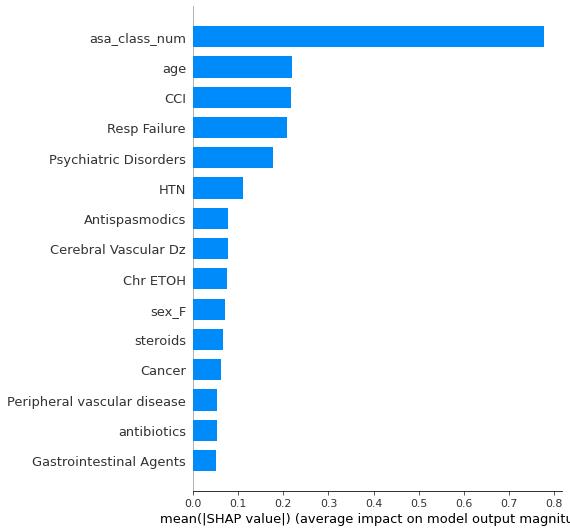

<Figure size 432x288 with 0 Axes>

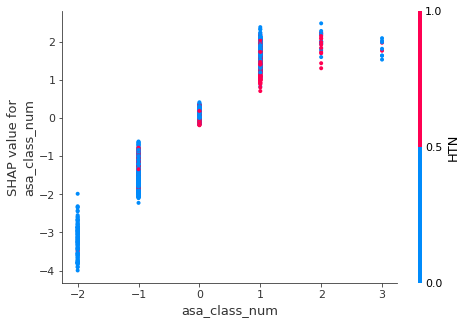

<Figure size 432x288 with 0 Axes>

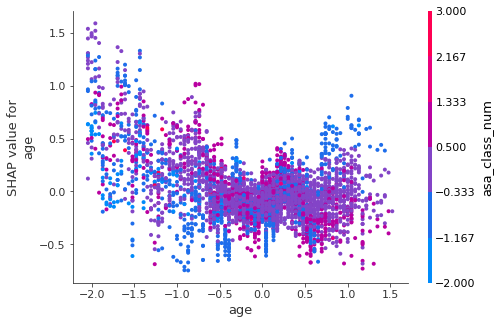

<Figure size 432x288 with 0 Axes>

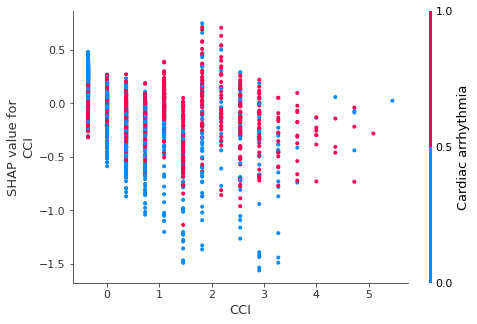

<Figure size 432x288 with 0 Axes>

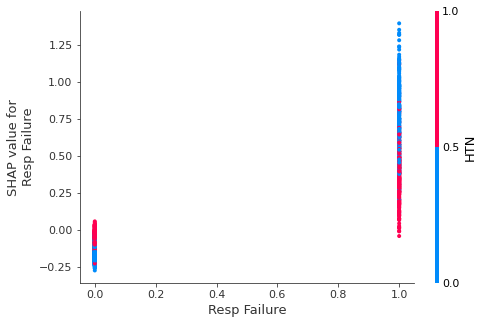

<Figure size 432x288 with 0 Axes>

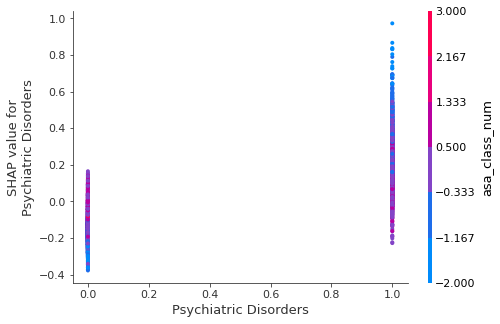

<Figure size 432x288 with 0 Axes>

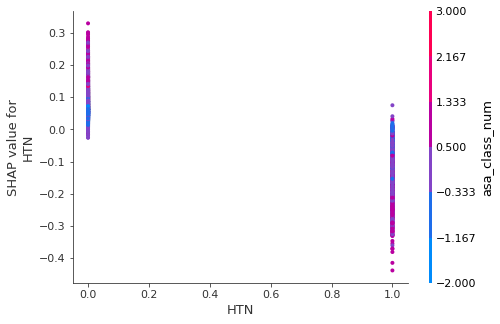


[surgery_related] Top 15 SHAP features:


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
0,duration,1.308867
2,EYE,0.284998
11,asa_emerg_flag,0.160685
7,Neurosurgery,0.128962
9,Thoracic,0.114693
8,Orthopedics,0.084472
3,GU,0.076205
5,General Surgery,0.045349
1,ENT,0.042225
4,GYN,0.038278


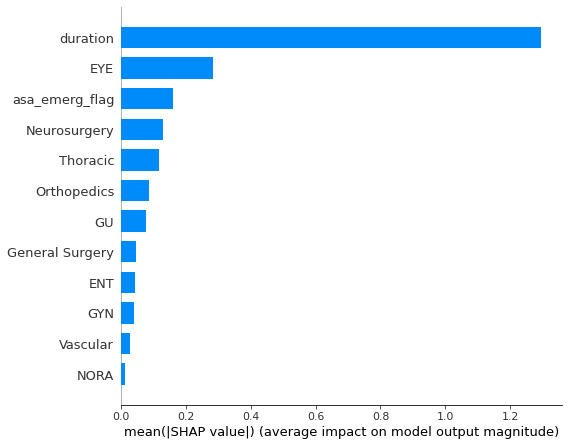

<Figure size 432x288 with 0 Axes>

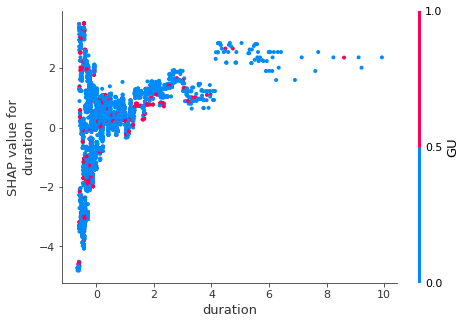

<Figure size 432x288 with 0 Axes>

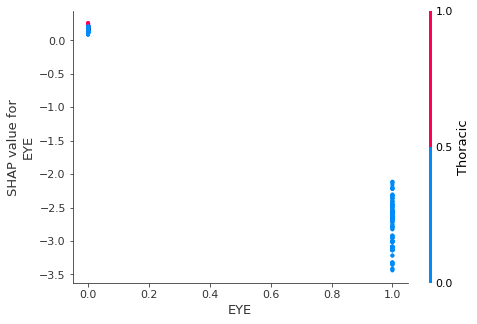

<Figure size 432x288 with 0 Axes>

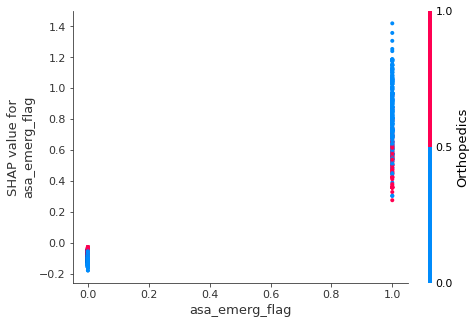

<Figure size 432x288 with 0 Axes>

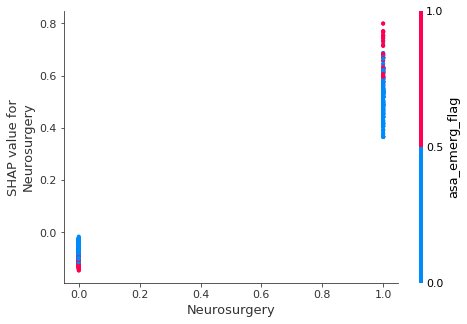

<Figure size 432x288 with 0 Axes>

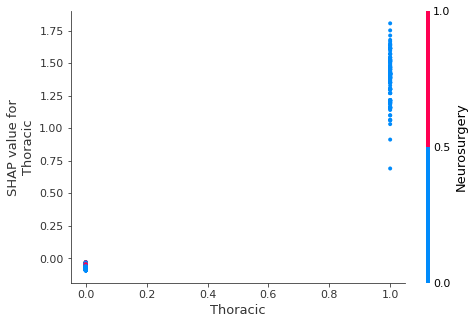

<Figure size 432x288 with 0 Axes>

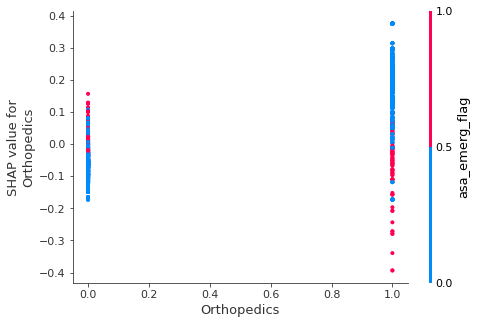


[anesthetics_related] Top 15 SHAP features:


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
0,map_65_95_min,0.429750
24,phenylephrine,0.251655
27,rocuronium,0.243399
25,propofol,0.239637
6,total_mac_hrs,0.223347
5,map_min,0.202027
2,map_lt_65_min,0.178486
1,map_gt_95_min,0.160766
4,map_mean,0.156065
3,map_max,0.154152


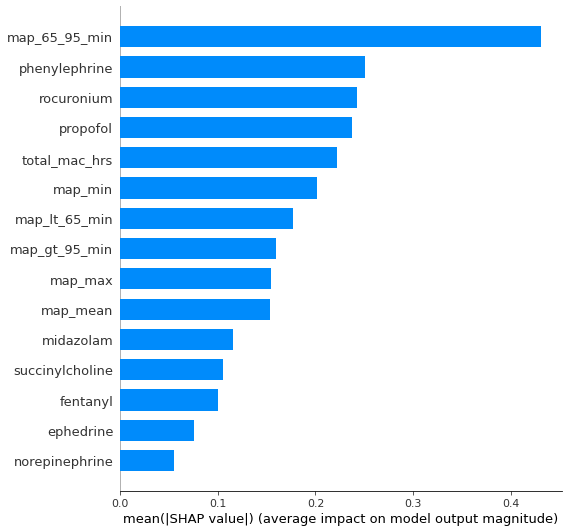

<Figure size 432x288 with 0 Axes>

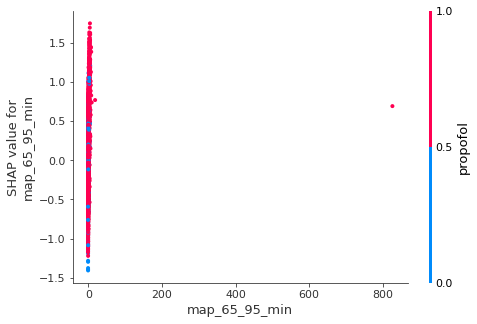

<Figure size 432x288 with 0 Axes>

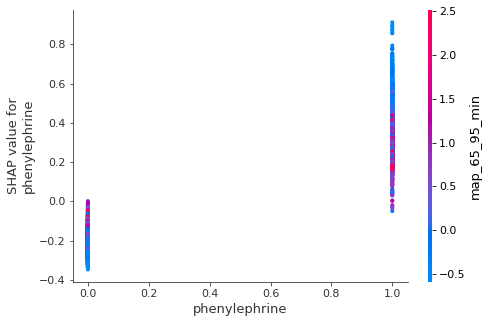

<Figure size 432x288 with 0 Axes>

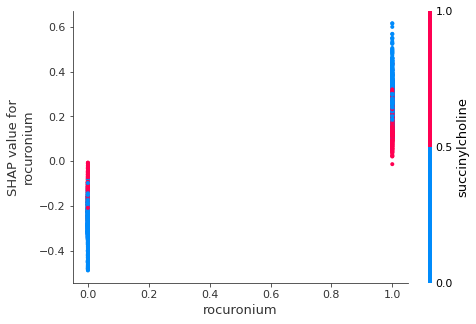

<Figure size 432x288 with 0 Axes>

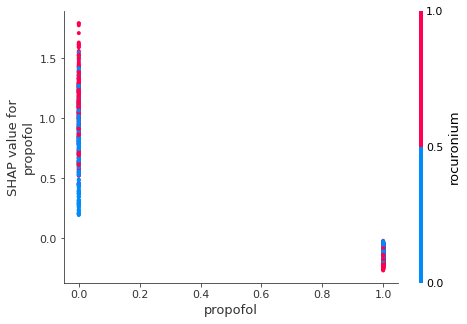

<Figure size 432x288 with 0 Axes>

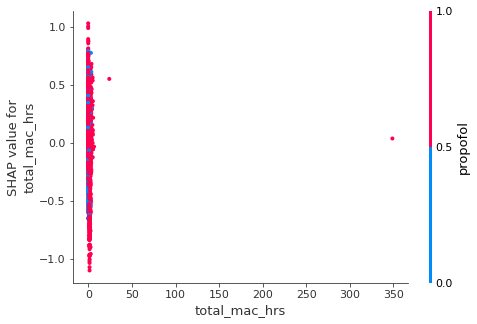

<Figure size 432x288 with 0 Axes>

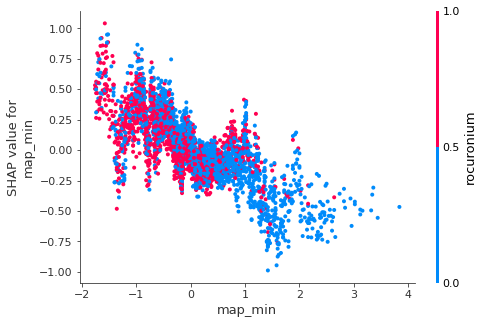


Saved per-domain SHAP artifacts to artifacts/shap/


In [32]:
# E) Per-domain feature-level SHAP (global + dependence)

import json, joblib, numpy as np, pandas as pd
import shap, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

# Load schema/spec/domains
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)
with open("artifacts/preprocessor_spec.json", "r") as f:
    spec = json.load(f)
with open("artifacts/domains.json", "r") as f:
    domains = json.load(f)

TARGET       = schema["target"]
EXCLUDED     = set(schema.get("exclude_cols", []))
present_cont = spec["present_cont"]
present_cat  = spec["present_cat"]
present_bin  = spec["present_bin"]

# Helper: build unfitted preprocessor restricted to chosen columns
def make_preprocessor(cols_subset):
    cont = [c for c in present_cont if c in cols_subset]
    cat  = [c for c in present_cat  if c in cols_subset]
    biny = [c for c in present_bin  if c in cols_subset]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)
    cont_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale",  RobustScaler())])
    cat_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("ohe",    ohe)])
    bin_pipe  = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])
    return ColumnTransformer(
        transformers=[
            ("cont", cont_pipe, cont),
            ("cat",  cat_pipe,  cat),
            ("bin",  bin_pipe,  biny),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

# Base LGBM params
lgbm_params = dict(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=-1,
    verbosity=-1,
)

# Data: drop target/IDs/admin
X_cols = [c for c in df_mod.columns if c not in EXCLUDED | {TARGET}]
y = df_mod[TARGET].astype(int).values

# Use the current domain setup by default
domains_to_explain = list(domains.keys())

outdir = Path("artifacts/shap")
outdir.mkdir(parents=True, exist_ok=True)

for dname in domains_to_explain:
    dcols = [c for c in domains[dname] if c in X_cols]
    if not dcols:
        print(f"[{dname}] No usable columns. Skipping.")
        continue

    # Fit domain pipeline on ALL data (global explanation)
    prep = make_preprocessor(dcols)
    clf  = LGBMClassifier(**lgbm_params)
    pipe = Pipeline([("prep", prep), ("clf", clf)])
    pipe.fit(df_mod[dcols], y)

    # Transform features & get feature names after preprocessing
    X_trans = pipe.named_steps["prep"].transform(df_mod[dcols])
    feat_names = pipe.named_steps["prep"].get_feature_names_out()

    # Tree SHAP
    explainer = shap.TreeExplainer(pipe.named_steps["clf"])
    sv = explainer.shap_values(X_trans)
    # LightGBM binary often returns [class0, class1]
    if isinstance(sv, list) and len(sv) == 2:
        sv = sv[1]

    # Global importance table (mean |SHAP|)
    mean_abs = np.abs(sv).mean(axis=0)
    shap_imp = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
    shap_imp.to_csv(outdir / f"{dname}_global_importance.csv", index=False)
    print(f"\n[{dname}] Top 15 SHAP features:")
    display(shap_imp.head(15))

    # Convert sparse to dense for plotting
    X_plot = X_trans
    if hasattr(X_plot, "toarray"):
        # Sample up to 4000 rows to keep RAM reasonable for plots
        idx = np.random.RandomState(42).choice(X_plot.shape[0], size=min(4000, X_plot.shape[0]), replace=False)
        X_plot = X_plot[idx].toarray()
        sv_plot = sv[idx]
    else:
        idx = np.random.RandomState(42).choice(X_plot.shape[0], size=min(4000, X_plot.shape[0]), replace=False)
        X_plot = X_plot[idx]
        sv_plot = sv[idx]

    # Global plots
    plt.figure(figsize=(8,5))
    shap.summary_plot(sv_plot, X_plot, feature_names=feat_names, plot_type="bar", show=True, max_display=15)
    plt.title(f"{dname} — SHAP global importance")
    plt.tight_layout()
    plt.savefig(outdir / f"{dname}_bar.png", dpi=200)
    plt.close()

    plt.figure(figsize=(9,6))
    shap.summary_plot(sv_plot, X_plot, feature_names=feat_names, show=False, max_display=15)
    plt.title(f"{dname} — SHAP beeswarm")
    plt.tight_layout()
    plt.savefig(outdir / f"{dname}_beeswarm.png", dpi=600)
    plt.close()

    # Dependence plots for the top features (with interaction suggestion)
    top_feats = shap_imp["feature"].head(6).tolist()
    for f in top_feats:
        plt.figure(figsize=(6,4))
        try:
            shap.dependence_plot(f, sv_plot, X_plot, feature_names=feat_names, show=True, interaction_index="auto")
        except Exception:
            # Fallback: manual scatter if anything odd occurs
            j = list(feat_names).index(f)
            vals = X_plot[:, j]
            plt.scatter(vals, sv_plot[:, j], s=6, alpha=0.4)
            plt.xlabel(f); plt.ylabel("SHAP value")
        plt.title(f"{dname} — SHAP dependence: {f}")
        plt.tight_layout()
        plt.savefig(outdir / f"{dname}_depend_{f.replace('/','_')}.png", dpi=800)
        plt.close()

    # Save fitted domain pipeline in case we need per-domain predictions later
    joblib.dump(pipe, outdir / f"{dname}_pipeline.joblib")

print("\nSaved per-domain SHAP artifacts to artifacts/shap/")


# Calibration + ROC for META-LEARNER


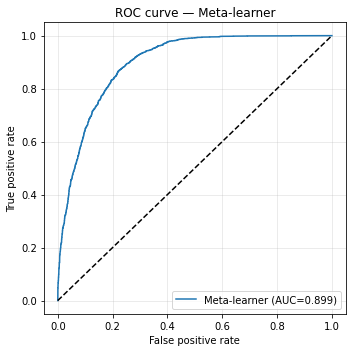

Saved ROC plot → artifacts/plots/roc_meta_learner.png


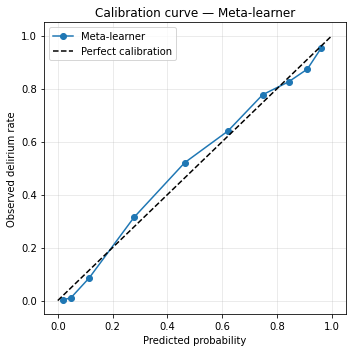

Saved calibration plot → artifacts/plots/calibration_meta_learner.png


In [33]:
# D2) Calibration + ROC for META-LEARNER

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, roc_auc_score

# Load true labels
y = df_mod["del_1"].astype(int).values

# Load meta-learner OOF probabilities
meta_oof = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values

# Make output folder
plot_dir = "artifacts/plots"
os.makedirs(plot_dir, exist_ok=True)

# ROC curve
fpr, tpr, _ = roc_curve(y, meta_oof)
auc_val = roc_auc_score(y, meta_oof)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"Meta-learner (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve — Meta-learner")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

fname = os.path.join(plot_dir, "roc_meta_learner.png")
plt.savefig(fname, dpi=500)
plt.show()

print(f"Saved ROC plot → {fname}")


# Calibration curve
frac_pos, mean_pred = calibration_curve(y, meta_oof, n_bins=10, strategy="quantile")

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, "o-", label="Meta-learner")
plt.plot([0,1],[0,1],"k--", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed delirium rate")
plt.title("Calibration curve — Meta-learner")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()

fname = os.path.join(plot_dir, "calibration_meta_learner.png")
plt.savefig(fname, dpi=500)
plt.show()

print(f"Saved calibration plot → {fname}")


# Calibration intercept + slope for META-LEARNER (OOF probs)

In [29]:
# D3) Calibration intercept + slope for META-LEARNER (OOF probs)

import numpy as np
import pandas as pd
import statsmodels.api as sm

def logit(p):
    p = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def prevalence_recalibrate(p_hat, pi_source, pi_target):
    """
    Intercept-only (prior) adjustment:
      logit(p_adj) = logit(p_hat) + logit(pi_target) - logit(pi_source)
    """
    return inv_logit(logit(p_hat) + (logit(pi_target) - logit(pi_source)))

def calibration_intercept_slope(y_true, p_pred):
    """
    Fit: logit(y) ~ intercept + slope * logit(p_pred)
    Returns calibration intercept and slope.
    """
    y_true = np.asarray(y_true).astype(int)
    lp = logit(p_pred)

    X = sm.add_constant(lp)  # const + lp
    model = sm.Logit(y_true, X).fit(disp=False)

    intercept = float(model.params[0])
    slope     = float(model.params[1])

    # Wald-style CI
    ci = model.conf_int()
    ci = np.asarray(ci)

    intercept_ci = (float(ci[0, 0]), float(ci[0, 1]))
    slope_ci     = (float(ci[1, 0]), float(ci[1, 1]))

    return {
        "calibration_intercept": intercept,
        "calibration_slope": slope,
        "intercept_ci_low": intercept_ci[0],
        "intercept_ci_high": intercept_ci[1],
        "slope_ci_low": slope_ci[0],
        "slope_ci_high": slope_ci[1],
    }

# Load labels + OOF meta probabilities (same inputs as D2/D4)
y = df_mod["del_1"].astype(int).values
p_oof = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values

# 1) Calibration in the analyzed case–control sample (OOF)
res_oof = calibration_intercept_slope(y, p_oof)
print("META-LEARNER calibration on OOF probabilities (case–control sample):")
print(f"  intercept = {res_oof['calibration_intercept']:.3f} "
      f"[{res_oof['intercept_ci_low']:.3f}, {res_oof['intercept_ci_high']:.3f}]")
print(f"  slope     = {res_oof['calibration_slope']:.3f} "
      f"[{res_oof['slope_ci_low']:.3f}, {res_oof['slope_ci_high']:.3f}]")

rows = []
rows.append({"version": "oof_case_control", "pi_target": np.nan, **res_oof})

# 2) calibration after prevalence adjustment (for our case–control paper)
pi_source = float(y.mean())  # ≈ 0.50 by design
for pi_target in [0.10, 0.20, 0.40]:
    p_adj = prevalence_recalibrate(p_oof, pi_source=pi_source, pi_target=pi_target)
    res_adj = calibration_intercept_slope(y, p_adj)

    print(f"\nAfter prevalence adjustment to π={pi_target:.2f}:")
    print(f"  intercept = {res_adj['calibration_intercept']:.3f} "
          f"[{res_adj['intercept_ci_low']:.3f}, {res_adj['intercept_ci_high']:.3f}]")
    print(f"  slope     = {res_adj['calibration_slope']:.3f} "
          f"[{res_adj['slope_ci_low']:.3f}, {res_adj['slope_ci_high']:.3f}]")

    rows.append({"version": "oof_prev_adjusted", "pi_target": pi_target, **res_adj})

# Save for reporting
out = pd.DataFrame(rows)
out_path = "artifacts/calibration_meta_learner_slope_intercept.csv"
out.to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")


META-LEARNER calibration on OOF probabilities (case–control sample):
  intercept = -0.006 [-0.083, 0.070]
  slope     = 1.035 [0.982, 1.088]

After prevalence adjustment to π=0.10:
  intercept = 2.268 [2.137, 2.399]
  slope     = 1.035 [0.982, 1.088]

After prevalence adjustment to π=0.20:
  intercept = 1.428 [1.329, 1.528]
  slope     = 1.035 [0.982, 1.088]

After prevalence adjustment to π=0.40:
  intercept = 0.413 [0.337, 0.490]
  slope     = 1.035 [0.982, 1.088]

Saved → artifacts/calibration_meta_learner_slope_intercept.csv


# Prevalence (prior) adjustment + WEIGHTED DCA

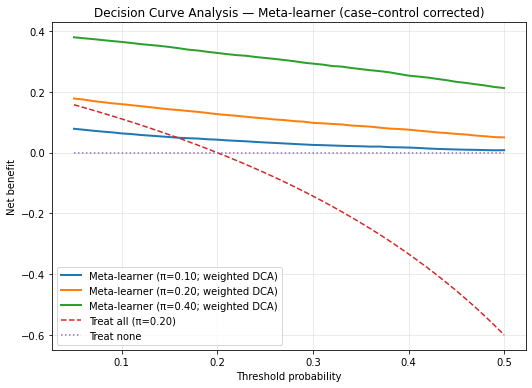

Source prevalence (case–control sample): 0.500
Saved weighted multi-π DCA plot → artifacts/plots/dca_meta_learner_weighted_multi_pi.png


In [34]:
# D4: prevalence (prior) adjustment + WEIGHTED DCA
# - Adjust predicted probabilities to target prevalence (intercept-only prior shift)
# - Compute decision curves using inverse-probability weights so net benefit targets population π
# - Repeat across multiple plausible prevalences (e.g., 0.10 / 0.20 / 0.40)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# helpers
def logit(p):
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def prevalence_recalibrate(p_hat, pi_source, pi_target, eps=1e-6):
    """
    Intercept-only (prior) adjustment for case–control sampling:
      logit(p_adj) = logit(p_hat) + logit(pi_target) - logit(pi_source)
    """
    p_hat = np.clip(np.asarray(p_hat), eps, 1 - eps)
    delta = logit(pi_target) - logit(pi_source)
    return inv_logit(logit(p_hat) + delta)

def weighted_decision_curve(y_true, p_pred, thresholds, w_case=1.0, w_ctrl=1.0):
    """
    Weighted DCA to approximate population net benefit under case–control sampling.

    Net benefit at threshold pt:
      NB = (wTP / wN) - (pt/(1-pt)) * (wFP / wN)

    where wTP and wFP are weighted counts; wN is total weight.

    Treat-all curve uses target prevalence (pi_target) by construction (see below).
    Treat-none is 0.
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

    w = np.where(y_true == 1, w_case, w_ctrl)
    wN = w.sum()

    nb_model = np.zeros_like(thresholds, dtype=float)
    nb_all   = np.zeros_like(thresholds, dtype=float)
    nb_none  = np.zeros_like(thresholds, dtype=float)

    # Weighted prevalence implied by weights (should match pi_target if weights set correctly)
    pi_w = (w[y_true == 1].sum()) / wN

    for i, pt in enumerate(thresholds):
        wt = pt / (1 - pt)

        preds = (p_pred >= pt).astype(int)
        TP_w = w[(preds == 1) & (y_true == 1)].sum()
        FP_w = w[(preds == 1) & (y_true == 0)].sum()

        nb_model[i] = (TP_w / wN) - wt * (FP_w / wN)

        # Treat-all under population prevalence pi_w (≈ pi_target)
        nb_all[i] = pi_w - wt * (1 - pi_w)

    return nb_model, nb_all, nb_none, pi_w

# load labels + OOF meta probabilities
y = df_mod["del_1"].astype(int).values
p_oof = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values

# Source prevalence in the case–control analysis set
pi_source = float(y.mean())

# Target prevalences to report (choosing clinically plausible values for our setting)
pi_targets = [0.10, 0.20, 0.40]

# Threshold grid
thresholds = np.linspace(0.05, 0.50, 46)  # 0.05, 0.06, ..., 0.50

# Output folder
os.makedirs("artifacts/plots", exist_ok=True)

# run and plot
plt.figure(figsize=(7.5, 5.5))

for pi_target in pi_targets:
    # 1) prior-adjust probabilities to target prevalence
    p_adj = prevalence_recalibrate(p_oof, pi_source=pi_source, pi_target=pi_target)

    # 2) inverse-probability weights to recover population prevalence in net benefit
    #    These weights make the weighted prevalence equal to pi_target:
    w_case = pi_target / pi_source
    w_ctrl = (1 - pi_target) / (1 - pi_source)

    nb_model, nb_all, nb_none, pi_w = weighted_decision_curve(
        y_true=y, p_pred=p_adj, thresholds=thresholds, w_case=w_case, w_ctrl=w_ctrl
    )

    plt.plot(
        thresholds, nb_model,
        linewidth=2,
        label=f"Meta-learner (π={pi_target:.2f}; weighted DCA)"
    )

# Show treat-all/none for a reference prevalence
# Here: showing treat-all/none for π=0.20 as a reference
ref_pi = 0.20
w_case_ref = ref_pi / pi_source
w_ctrl_ref = (1 - ref_pi) / (1 - pi_source)
_, nb_all_ref, nb_none_ref, pi_w_ref = weighted_decision_curve(
    y_true=y,
    p_pred=prevalence_recalibrate(p_oof, pi_source=pi_source, pi_target=ref_pi),
    thresholds=thresholds,
    w_case=w_case_ref,
    w_ctrl=w_ctrl_ref
)

plt.plot(thresholds, nb_all_ref, linestyle="--", label=f"Treat all (π={ref_pi:.2f})")
plt.plot(thresholds, nb_none_ref, linestyle=":", label="Treat none")

plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis — Meta-learner (case–control corrected)")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()

fname = "artifacts/plots/dca_meta_learner_weighted_multi_pi.png"
plt.savefig(fname, dpi=500)
plt.show()

print(f"Source prevalence (case–control sample): {pi_source:.3f}")
print(f"Saved weighted multi-π DCA plot → {fname}")


In [ ]:
# End of Notebook